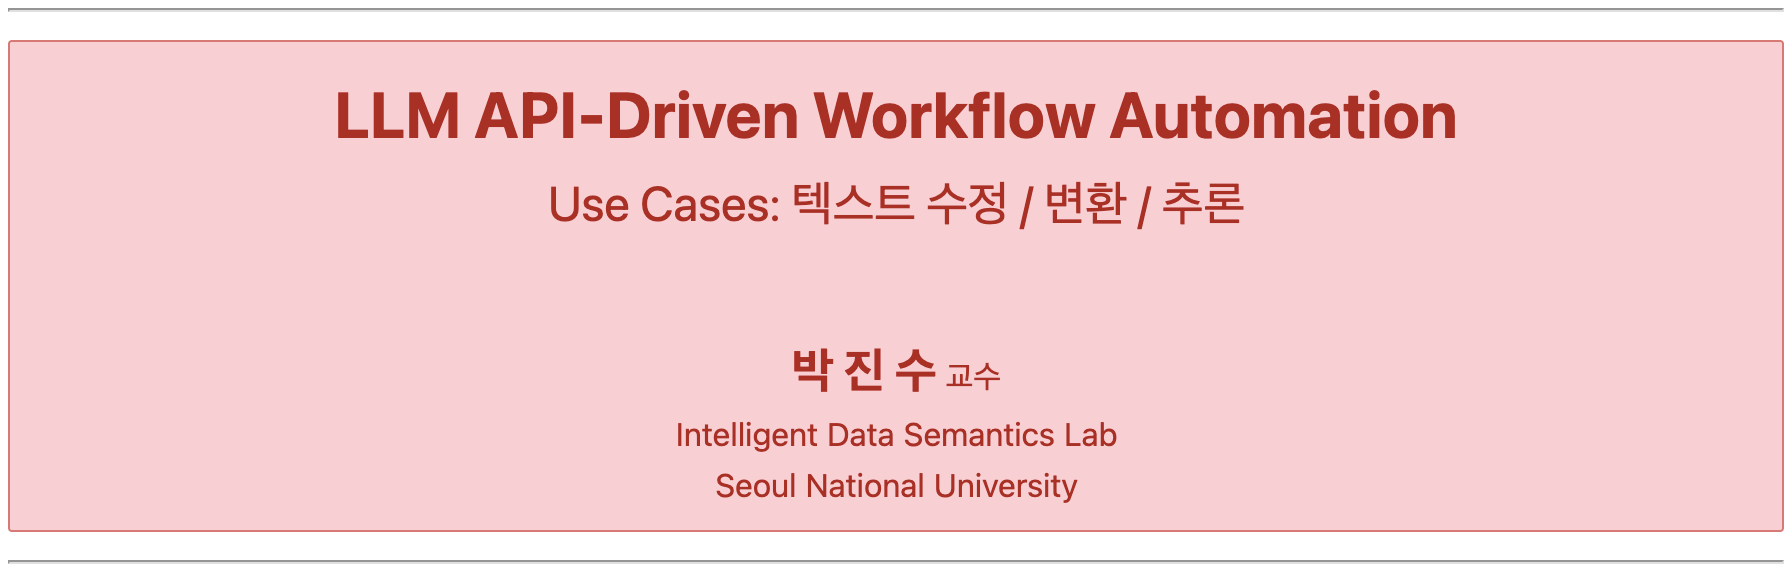

- - -    

- 본 자료는 강의를 위한 목적으로 제작되었습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#도우미-함수-가져오기" data-toc-modified-id="도우미-함수-가져오기-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>도우미 함수 가져오기</a></span></li><li><span><a href="#문장-오류-수정" data-toc-modified-id="문장-오류-수정-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>문장 오류 수정</a></span></li><li><span><a href="#Lab:-여러-문장의-오류-수정" data-toc-modified-id="Lab:-여러-문장의-오류-수정-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Lab: 여러 문장의 오류 수정</a></span></li><li><span><a href="#형식-변환" data-toc-modified-id="형식-변환-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>형식 변환</a></span></li><li><span><a href="#어조-변환" data-toc-modified-id="어조-변환-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>어조 변환</a></span></li><li><span><a href="#여러-언어로-동시-번역" data-toc-modified-id="여러-언어로-동시-번역-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>여러 언어로 동시 번역</a></span></li><li><span><a href="#Lab:-범용-번역기" data-toc-modified-id="Lab:-범용-번역기-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Lab: 범용 번역기</a></span></li><li><span><a href="#사고-추론-과정-검증" data-toc-modified-id="사고-추론-과정-검증-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>사고 추론 과정 검증</a></span></li></ul></div>

# 패키지 설치 및 API 설정

**API Key 발급 방법**
- MistralAI: https://drive.google.com/file/d/1eiRVg-hTGhN2SrJz0R7Qsn0ZS6Pw7HHd/view?usp=sharing
- Groq: https://drive.google.com/file/d/1E267hPCwahSbaKWVeCPQp2ksW8T9VsTG/view?usp=sharing
- Google Gemini: https://drive.google.com/file/d/1YLy4B4RkD6Y3HnpScpKd0trPZxKvUsXa/view?usp=sharing
- Anthropic: https://drive.google.com/file/d/1u9q-0_gCc6wmRAXNctQj8ApLRhOtYYpX/view?usp=sharing
- OpenAI: https://drive.google.com/file/d/122mEaoTYAYOPehBfChfOkNLHbZrDge3C/view?usp=sharing

In [ ]:
!python -m pip install -qU python-dotenv redlines langchain # YOUR LLM package HERE (e.g., ollama 'langchain[ollama]' mistralai 'langchain[mistralai]' groq 'langchain[groq]' google-genai 'langchain[google-genai]' anthropic 'langchain[anthropic]' openai 'langchain[openai]')
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 (API Key 명칭 수정 후 사용) - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

In [1]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

Enter Your LLM API Key:  ········


In [ ]:
# 방법 3 (API Key 명칭 수정 후 사용) - (caution) API 키 노출 주의
import os
os.environ['?????_API_KEY'] = 'YOUR-LLM-API-KEY'

# 도우미 함수 가져오기


In [ ]:
# --- utils.py 다운로드
!gdown 1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi -O utils.py

**<u><font size='+1'>도우미 함수 사용법</font></u>**


**get_llm_response**(instruction, user_message, model, messages, **kwargs)
- `instruction`에 시스템 지침을, `user_message`에 사용자 입력을 전달하면 LangChain 기반으로 LLM을 호출해 응답 텍스트를 반환한다.
- `messages`에 LangChain 메시지 객체 리스트(`SystemMessage`, `HumanMessage`, `AIMessage` 등)를 직접 전달할 수도 있다. 이 경우 `instruction`과 `user_message`는 무시된다.
- `model`에 사용할 모델 ID를 전달한다 (예: `'openai:gpt-5.4-mini'`, `'google_genai:gemini-2.5-flash'`, `'anthropic:claude-sonnet-4-5-20250929'`).
    + **<font color='tomato'>이 함수의 기본 모델은 `'google_genai:gemini-3.1-flash-lite'`이다.</font>**
    + LangChain에서 사용할 수 있는 모델 이름(ID)과 형식은 공식 문서에서 확인할 수 있다.
        * https://reference.langchain.com/python/langchain/chat_models/base/init_chat_model
- `**kwargs`로 `temperature`, `max_output_tokens` 등 모델별 추가 파라미터를 전달할 수 있다.
    + 💡 참고: GPT-5를 비롯한 일부 추론 모델은 `temperature` 등 일부 파라미터를 지원하지 않는다.
- Gemini, Claude 등 일부 모델이 반환하는 블록 형태의 응답도 내부에서 자동으로 처리해 순수 텍스트만 반환한다.

**사용 예시**
```python
response = get_llm_response(instruction, user_message) # 기본값이 'google_genai:gemini-3.1-flash-lite'
response = get_llm_response(instruction, user_message, model='google_genai:gemini-3.1-flash-lite')
response = get_llm_response(instruction, user_message, model='openai:gpt-5.4-mini')
response = get_llm_response(instruction, user_message, model='anthropic:claude-haiku-4-5')
```

# 문장 오류 수정

In [63]:
# --- 방법 1 : 오류 수정 (redlines) 
from IPython.display import Markdown
from redlines import Redlines
from utils import get_llm_response 

instruction = '''사용자가 제공한 문장에서 맞춤법과 문법 오류만 수정하세요.
오류가 있는 단어나 표현만 고치고, 나머지는 원문 그대로 유지하세요.
수정된 문장만 출력하고 설명, 주석, 추가 텍스트는 절대 포함하지 마세요.
'''
user_message = '''내일은 날씨가 맑을 꺼에요. 
그래서 나는 내일 학교에 갈께요. 나는 연구실에서 조용이 컴퓨터로 작업하기를 선호합나다. 
그 덕분에 나의 논문이 유명 학술지에 개재되었습니다. 그나저나 너는 어떻게 지내고 잇어?'
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 시스템 프롬프트로 LLM을 호출해 교정된 문장을 받고, 원문과 비교하여 변경 사항을 마크다운으로 출력한다.

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

내일은 날씨가 맑을 <span style='color:red;font-weight:700;text-decoration:line-through;'>꺼에요. </span><span style='color:green;font-weight:700;'>거예요. </span>

그래서 나는 내일 학교에 <span style='color:red;font-weight:700;text-decoration:line-through;'>갈께요. </span><span style='color:green;font-weight:700;'>갈게요. </span>나는 연구실에서 <span style='color:red;font-weight:700;text-decoration:line-through;'>조용이 </span><span style='color:green;font-weight:700;'>조용히 </span>컴퓨터로 작업하기를 <span style='color:red;font-weight:700;text-decoration:line-through;'>선호합나다. </span><span style='color:green;font-weight:700;'>선호합니다. </span>

그 덕분에 나의 논문이 유명 학술지에 <span style='color:red;font-weight:700;text-decoration:line-through;'>개재되었습니다. </span><span style='color:green;font-weight:700;'>게재되었습니다. </span>그나저나 너는 어떻게 지내고 <span style='color:red;font-weight:700;text-decoration:line-through;'>잇어?'</span><span style='color:green;font-weight:700;'>있어요?</span>

In [67]:
# --- 방법 2 : 오류 수정 (JSON)
instruction = '''사용자가 제공한 문장에서 맞춤법과 문법 오류만 수정하세요.
수정된 문장을 먼저 출력하고, 반드시 다음 JSON 형식만 출력하세요.
JSON 앞뒤로 어떠한 텍스트, 설명, 주석도 절대 포함하지 마세요.

{
  "수정 전": ["수정 전 단어1", "수정 전 단어2"], 
  "수정 후": ["수정 후 단어1", "수정 후 단어2"]
}
'''
user_message = '''내일은 날씨가 맑을 꺼에요. 
그래서 나는 내일 학교에 갈께요. 나는 연구실에서 조용이 컴퓨터로 작업하기를 선호합나다. 
그 덕분에 나의 논문이 유명 학술지에 개재되었습니다. 그나저나 너는 어떻게 지내고 잇어?'
'''
response = get_llm_response(instruction, user_message)
print(response)

{
  "수정 전": ["꺼에요", "갈께요", "조용이", "선호합나다", "개재되었습니다", "잇어"],
  "수정 후": ["거예요", "갈게요", "조용히", "선호합니다", "게재되었습니다", "있어"]
}


# Lab: 여러 문장의 오류 수정

- - -
시스템 지시문을 잘 작성하여 주어진 여러 문장을 아래 **실행 결과 예시**처럼 출력하도록 해보자.
- - -

**실행 결과 예시**
<pre>
수정 전: 저는 내일 학교에 갈께요.  
수정 후: 저는 내일 학교에 갈게요. 

수정 전: 그는 컴퓨터로 작업하기를 선호합나다.  
수정 후: 그는 컴퓨터로 작업하기를 선호합니다. 

수정 전: 그의 논문이 유명 학술지에 개재되었습니다.  
수정 후: 그의 논문이 유명 학술지에 게재되었습니다. 

수정 전: 내일은 날씨가 맑을 꺼에요.  
수정 후: 내일은 날씨가 맑을 거예요. 

수정 전: 너는 어떻게 지내고 잇어?  
수정 후: 너는 어떻게 지내고 있어? 

수정 전: 오늘 가장 화제가 되는 뉴스는 무엇인가요?  
수정 후: (오류 없음)     
</pre>

In [ ]:
instruction = '''
YOUR PROMPT HERE
'''

user_messages = (
  '저는 내일 학교에 갈께요.',
  '그는 컴퓨터로 작업하기를 선호합나다.',
  '그의 논문이 유명 학술지에 개재되었습니다.',
  '내일은 날씨가 맑을 꺼에요.',
  '너는 어떻게 지내고 잇어?',
  '오늘 가장 화제가 되는 뉴스는 무엇인가요?'
)

for user_message in user_messages:
    response = get_llm_response(instruction, user_message)
    print(response, '\n')

# 형식 변환

In [4]:
from IPython.display import display, HTML
from utils import get_llm_response

instruction = '''당신의 업무는 JSON 형식을 HTML 테이블로 변환하는 것입니다. 
제목은 <p style="text-align:center; font-size:2em; font-weight:bold;">제목</p> 형식으로 작성하세요.
HTML 문서에 제목도 추가해야 합니다. HTML 문서로만 변환하고 추가 설명은 하지 마세요.
그리고 답변의 시작과 끝에 HTML 코드를 표시하는 삼중 백틱(```html)을 반드시 생략하고 HTML 코드만 출력하세요.
'''
data = '''
{
    "전자 제품 목록": [
        {"제품명": "스마트 TV", "브랜드": "삼성", "모델": "QLED 8K", "가격": "2,500,000원"},
        {"제품명": "노트북", "브랜드": "LG", "모델": "그램 2023", "가격": "1,800,000원"},
        {"제품명": "스마트폰", "브랜드": "애플", "모델": "아이폰 15", "가격": "1,350,000원"},
        {"제품명": "블루투스 스피커", "브랜드": "소니", "모델": "SRS-XB23", "가격": "150,000원"},
        {"제품명": "전자레인지", "브랜드": "파나소닉", "모델": "NN-SD975S", "가격": "300,000원"},
        {"제품명": "냉장고", "브랜드": "삼성", "모델": "비스포크 4도어", "가격": "3,200,000원"},
        {"제품명": "세탁기", "브랜드": "LG", "모델": "트롬 오브제", "가격": "1,500,000원"},
        {"제품명": "에어컨", "브랜드": "캐리어", "모델": "인버터 스탠드형", "가격": "1,200,000원"},
        {"제품명": "공기청정기", "브랜드": "다이슨", "모델": "TP07", "가격": "850,000원"},
        {"제품명": "로봇청소기", "브랜드": "아이로봇", "모델": "룸바 j7+", "가격": "950,000원"},
        {"제품명": "태블릿", "브랜드": "애플", "모델": "아이패드 프로 12.9", "가격": "1,650,000원"},
        {"제품명": "스마트워치", "브랜드": "삼성", "모델": "갤럭시 워치 6", "가격": "380,000원"},
        {"제품명": "무선 이어폰", "브랜드": "소니", "모델": "WF-1000XM5", "가격": "350,000원"},
        {"제품명": "게이밍 모니터", "브랜드": "LG", "모델": "울트라기어 27인치", "가격": "550,000원"},
        {"제품명": "프린터", "브랜드": "캐논", "모델": "PIXMA G3010", "가격": "220,000원"},
        {"제품명": "외장 SSD", "브랜드": "삼성", "모델": "T7 Shield 1TB", "가격": "130,000원"},
        {"제품명": "웹캠", "브랜드": "로지텍", "모델": "C920 HD Pro", "가격": "110,000원"},
        {"제품명": "기계식 키보드", "브랜드": "레오폴드", "모델": "FC900R", "가격": "150,000원"},
        {"제품명": "무선 마우스", "브랜드": "로지텍", "모델": "MX Master 3S", "가격": "130,000원"},
        {"제품명": "NAS 저장장치", "브랜드": "시놀로지", "모델": "DS223j", "가격": "320,000원"},
        {"제품명": "빔프로젝터", "브랜드": "엡손", "모델": "EH-TW7400", "가격": "1,100,000원"},
        {"제품명": "전동칫솔", "브랜드": "오랄비", "모델": "IO 시리즈 9", "가격": "280,000원"},
        {"제품명": "식기세척기", "브랜드": "보쉬", "모델": "SMS4HCW40E", "가격": "980,000원"},
        {"제품명": "전기밥솥", "브랜드": "쿠쿠", "모델": "IH 10인용", "가격": "230,000원"},
        {"제품명": "커피머신", "브랜드": "드롱기", "모델": "마그니피카 에보", "가격": "750,000원"},
        {"제품명": "헤어드라이어", "브랜드": "다이슨", "모델": "슈퍼소닉", "가격": "550,000원"},
        {"제품명": "전기면도기", "브랜드": "필립스", "모델": "시리즈 9000", "가격": "320,000원"},
        {"제품명": "블랙박스", "브랜드": "아이나비", "모델": "QXD5000", "가격": "180,000원"},
        {"제품명": "스마트 도어락", "브랜드": "게이트맨", "모델": "V100", "가격": "250,000원"},
        {"제품명": "홈 CCTV", "브랜드": "아이피타임", "모델": "CAM-HD1080", "가격": "90,000원"}
    ]
}
'''
response = get_llm_response(instruction, data)
HTML(response)

제품명,브랜드,모델,가격
스마트 TV,삼성,QLED 8K,"2,500,000원"
노트북,LG,그램 2023,"1,800,000원"
스마트폰,애플,아이폰 15,"1,350,000원"
블루투스 스피커,소니,SRS-XB23,"150,000원"
전자레인지,파나소닉,NN-SD975S,"300,000원"
냉장고,삼성,비스포크 4도어,"3,200,000원"
세탁기,LG,트롬 오브제,"1,500,000원"
에어컨,캐리어,인버터 스탠드형,"1,200,000원"
공기청정기,다이슨,TP07,"850,000원"
로봇청소기,아이로봇,룸바 j7+,"950,000원"


# 어조 변환

In [7]:
# --- 문장 스타일 변환
from utils import get_llm_response

instruction = '''당신은 제공받은 문장을
정중하고 공식적인 문장 하나로 바꾸는 전문가입니다.
'''
user_message = '어이, 나는 홍길동인디, 이 노트북 사양 좀 줘봐.'
response = get_llm_response(instruction, user_message, model='openai:gpt-5.5')
print(response)

안녕하세요, 저는 홍길동이며, 이 노트북의 사양을 알려주시면 감사하겠습니다.


In [16]:
# --- 문장 스타일 변환
instruction = '''당신은 제공받은 문장을 
정중하고 공식적인 문장으로 바꾸는 전문가입니다.
불친절한 표현이 있다면 간결하면서도 친절하고 
예의바른 문장 하나로 바꿔주세요.
변환한 문장만 출력하세요. 
설명, 주석, 마크다운은 절대 포함하지 마세요.
'''
rude_sentences = [
    '야, 그것 좀 빨리 가져와 봐.',
    '너 뭐 하는 거야? 제대로 안 해?',
    '그거 하나도 제대로 못 하냐?',
    '말귀를 못 알아먹어?',
    '왜 이렇게 눈치가 없어?',  
    '좀 빨리빨리 움직여 봐.',
    '내가 하라는 대로 하면 되잖아.',
    '이거 하나 처리 못하냐 진짜?',
    '시키는 거나 잘해라.'    
]

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 각 불친절한 문장을 순회하며 시스템 프롬프트와 함께 LLM을 호출해 정중한 문장으로 변환하고 출력한다.

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
else:
    print('!!! 작업을 완료했습니다', '!' * 55)    

죄송하지만 그것을 조금 빨리 가져다주실 수 있을까요? 

현재 진행 상황을 다시 확인하시고 정확하게 처리해 주시기 바랍니다. 

해당 업무를 정확히 처리해 주실 수 있을까요? 

제 말씀을 이해하시기 어려우셨을까요? 

상황을 조금 더 세심하게 살펴봐 주시면 감사하겠습니다. 

조금 더 신속하게 진행해 주시면 감사하겠습니다. 

제가 요청드린 방식대로 진행해 주시면 감사하겠습니다. 

해당 건을 처리해 주실 수 있을까요? 

맡은 업무에 최선을 다해 주시기 바랍니다. 

!!! 작업을 완료했습니다 !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


# 여러 언어로 동시 번역

In [17]:
instruction = '''
당신은 사용자가 제공한 영어를 번역하는 다국어 번역 전문가입니다. 
사용자가 제공한 내용을 다음 형식에 맞추어 프랑스어, 아랍어, 스페인어, 중국어, 일본어, 한국어로 번역합니다.
French:
Arabic:
Spanish:
Chinese:
Japanese:
Korean:
'''
user_message = input('>>> ')  
response = get_llm_response(instruction, user_message)
print(response)

>>>  A little girl is playing the piano.


French: Une petite fille joue du piano.
Arabic: فتاة صغيرة تعزف على البيانو.
Spanish: Una niña pequeña está tocando el piano.
Chinese: 一个小女孩正在弹钢琴。
Japanese: 小さな女の子がピアノを弾いています。
Korean: 어린 소녀가 피아노를 치고 있습니다.


# Lab: 범용 번역기

- - -
시스템 지시문을 잘 작성하여 주어진 다양한 국가의 언어 문장들을 아래 **실행 결과 예시**처럼 출력하도록 해보자.
- - -

**실행 결과 예시**
<pre>
원어 (프랑스어): La batterie de mon téléphone est trop courte et dure à peine une journée.  
영어: The battery of my phone is too short and lasts barely a day.  
한국어: 제 전화 배터리가 너무 짧아서 하루도 채 가지 못합니다. 

원어 (스페인어): La calidad de la cámara de mi teléfono es mala, especialmente en condiciones de poca luz.  
영어: The quality of my phone's camera is poor, especially in low light conditions.  
한국어: 제 전화기 카메라의 화질이 좋지 않아요, 특히 조명이 어두운 상황에서는 더욱 그렇습니다. 

원어 (이탈리아어): Spesso riscontro chiamate perse e scarsa potenza del segnale con il mio telefono.  
영어: I often experience missed calls and poor signal strength with my phone.  
한국어: 저는 제 전화로 자주 통화가 끊기고 신호가 약한 경우를 겪습니다. 

원어 (러시아어): Сенсорный экран моего телефона не реагирует и иногда не регистрирует касания.  
영어: The touchscreen of my phone is unresponsive and sometimes does not register touches.  
한국어: 제 전화의 터치스크린이 반응하지 않으며 가끔 터치를 인식하지 않습니다. 

원어 (베트남어): Bản cập nhật phần mềm mới nhất đã làm cho điện thoại của tôi chạy chậm và hay gặp lỗi hơn.  
영어: The latest software update has made my phone run slower and encounter more errors.  
한국어: 최신 소프트웨어 업데이트로 인해 제 전화기가 더 느리게 작동하고 오류가 더 자주 발생하고 있습니다. 
</pre>

In [ ]:
instruction = '''
YOUR PROMPT HERE
'''
user_messages = (
  'La batterie de mon téléphone est trop courte et dure à peine une journée.', 
  'La calidad de la cámara de mi teléfono es mala, especialmente en condiciones de poca luz.',  
  'Spesso riscontro chiamate perse e scarsa potenza del segnale con il mio telefono.',  
  'Сенсорный экран моего телефона не реагирует и иногда не регистрирует касания.',  
  'Bản cập nhật phần mềm mới nhất đã làm cho điện thoại của tôi chạy chậm và hay gặp lỗi hơn.'  
)
for user_message in user_messages:
    response = get_llm_response(instruction, user_message)
    print(response, '\n')

# 사고 추론 과정 검증

In [20]:
instruction = f'''당신은 전자제품 회사의 판매 사원입니다.
고객 문의에 답변하려면 다음 단계를 따르세요.

1단계: 먼저 고객이 특정 제품 또는 제품들에 대한 문의를 하고 있는지 판단하세요. 이때 제품 카테고리는 고려하지 않습니다.

2단계: 고객이 특정 제품에 대해 묻는 경우, 해당 제품이 다음 목록에 있는지 확인하세요.

구매 가능한 제품 목록:
1. 제품: 스마트홈허브
   카테고리: 스마트홈 기기
   브랜드: 스마트코리아
   모델 번호: SH-HB100
   보증기간: 1년
   평점: 4.5
   기능: 음성 인식, 다양한 연결 기기 지원, 무선 연결
   설명: 다양한 스마트 기기를 제어하는 중앙 허브.
   가격: 150,000원

2. 제품: 에어쿨 휴대용 선풍기
   카테고리: 계절가전
   브랜드: 쿨한세상
   모델 번호: AC-PF200
   보증기간: 1년
   평점: 4.2
   기능: USB 충전, 3단계 바람 조절, 저소음
   설명: 여름철 필수 휴대용 선풍기.
   가격: 20,000원

3. 제품: 클린봇 로봇청소기
   카테고리: 생활가전
   브랜드: 클린월드
   모델 번호: CB-RV300
   보증기간: 2년
   평점: 4.7
   기능: 자동 장애물 감지, 스마트폰 연동, 무선 충전
   설명: 편리하게 청소를 도와주는 스마트 청소기.
   가격: 500,000원

4. 제품: 쿡마스터 전기레인지
   카테고리: 주방가전
   브랜드: 쿡코리아
   모델 번호: CK-ER500
   보증기간: 1년
   평점: 4.4
   기능: 터치스크린, 타이머 기능, 다양한 조리 메뉴
   설명: 빠르고 편리한 요리를 도와주는 전기레인지.
   가격: 120,000원

5. 제품: FreshFridge 냉장고
   분류: 주방가전
   브랜드: FreshFridge
   모델 번호: FF-RF300
   보증: 2년
   평점: 4.8
   특징: 300리터 용량, 냉동/냉장/김치 저장 가능, 스마트 연결 기능
   설명: 다용도 저장공간과 최신 기술을 탑재한 가정용 냉장고입니다.
   가격: 1,199,000원

6. 제품: CleanAir 공기청정기
   분류: 계절가전
   브랜드: CleanAir
   모델 번호: CA-AP100
   보증: 1년
   평점: 4.6
   특징: 4단계 필터, 자동 오염 감지, 저소음
   설명: 고성능 공기청정기로, 실내의 미세먼지와 악취를 효과적으로 제거합니다.
   가격: 299,000원

7. 제품: SoundMax 무선 스피커
   분류: TV/음향
   브랜드: SoundMax
   모델 번호: SM-WS500
   보증: 1년
   평점: 4.7
   특징: 블루투스 연결, 24시간 연속재생, 방수 기능
   설명: 뛰어난 음질과 긴 배터리 수명을 자랑하는 프리미엄 무선 스피커입니다.
   가격: 149,000원

3단계: 문의 메시지가 위의 목록에 있는 제품을 포함하고 있다면, 고객이 문의하는 메시지에서 가정하는 내용을 나열하세요.
예를 들어, 가전 제품 A의 평점이 B 보다 높다던가, 가전 제품 C의 보증 기간이 2년이다와 같은 가정입니다.

4단계: 고객이 어떤 가정을 했다면, 그 가정이 제품 정보에 기반한 사실인지를 확인하세요.

5단계: 먼저 고객이 잘못된 가정을 했다면, 고객의 잘못된 가정을 정중하게 바로 잡아주세요.

매장에서 판매하는 상품은 여기 있는 7개 뿐이니 7개의 구매 가능한 제품 목록에 있는 가전 제품만 언급하거나 참조하세요. 

고객에게 친절한 어조로 답변하세요.

반드시 다음 형식을 사용하세요. '4단계' 다음에는 '5단계'가 아닌 '고객에 대한 응답'으로 출력하세요:

1단계: (1단계에 대한 추론을 설명하세요.)
2단계: (2단계에 대한 추론을 설명하세요.)
3단계: (3단계에 대한 추론을 설명하세요.)
4단계: (4단계에 대한 추론을 설명하세요.)
고객에 대한 응답: 고객에게 설명하세요.
'''
user_message = input('>>> ')  
response = get_llm_response(instruction, user_message)
print(response)

>>>  노트북 컴퓨터 중 저렴한 가격의 제품이 있나요?


1단계: 고객님께서 '노트북 컴퓨터'라는 특정 제품군에 대해 문의하고 계십니다.

2단계: 현재 저희 매장에서 판매 가능한 7개의 제품 목록(스마트홈허브, 에어쿨 휴대용 선풍기, 클린봇 로봇청소기, 쿡마스터 전기레인지, FreshFridge 냉장고, CleanAir 공기청정기, SoundMax 무선 스피커)을 확인한 결과, 문의하신 '노트북 컴퓨터'는 판매하고 있지 않습니다.

3단계: 고객님께서는 매장에서 노트북 컴퓨터를 판매하고 있으며, 그중 저렴한 모델이 있을 것이라는 가정을 하고 계십니다.

4단계: 고객님의 가정은 현재 저희 매장의 판매 목록과 일치하지 않는 잘못된 정보입니다. 저희 매장에서는 노트북을 취급하지 않고 있습니다.

고객에 대한 응답: 안녕하세요, 고객님! 저희 매장을 찾아주셔서 감사합니다. 문의하신 노트북 컴퓨터에 대해 안내해 드리고 싶으나, 아쉽게도 현재 저희 매장에서는 노트북을 판매하고 있지 않습니다. 대신 스마트홈 기기, 계절가전, 생활가전, 주방가전 및 음향기기 등 다양한 제품들을 보유하고 있습니다. 혹시 다른 필요한 가전제품이 있으시다면 언제든 편하게 말씀해 주세요. 친절히 도와드리겠습니다!


In [21]:
user_message = input('>>> ')  
response = get_llm_response(instruction, user_message)
print(response)

>>>  CleanAir 공기청정기가 클린봇 로봇청소기보다 얼마나 비쌉니까?


1단계: 고객님께서 'CleanAir 공기청정기'와 '클린봇 로봇청소기'라는 특정 두 제품에 대해 가격을 비교하고자 문의하셨습니다.

2단계: 문의하신 'CleanAir 공기청정기'(목록 6번)와 '클린봇 로봇청소기'(목록 3번) 모두 구매 가능한 제품 목록에 포함되어 있음을 확인하였습니다.

3단계: 고객님께서는 'CleanAir 공기청정기가 클린봇 로봇청소기보다 비쌀 것'이라는 가정을 바탕으로 가격 차이를 묻고 계십니다.

4단계: CleanAir 공기청정기의 가격은 299,000원이고, 클린봇 로봇청소기의 가격은 500,000원입니다. 따라서 고객님의 가정은 사실과 다릅니다. 클린봇 로봇청소기가 공기청정기보다 201,000원 더 비쌉니다.

고객에 대한 응답: 안녕하세요! 문의하신 제품의 가격에 대해 안내해 드리겠습니다.

고객님께서 CleanAir 공기청정기가 더 비쌀 것이라고 생각하신 것 같으나, 실제로는 클린봇 로봇청소기의 가격이 더 높습니다. 상세 가격을 비교해 드리면 다음과 같습니다.

- 클린봇 로봇청소기(CB-RV300): 500,000원
- CleanAir 공기청정기(CA-AP100): 299,000원

따라서 클린봇 로봇청소기가 CleanAir 공기청정기보다 201,000원 더 비싸게 판매되고 있습니다. 제품 선택에 도움이 되시길 바랍니다. 추가로 궁금한 점이 있으시면 언제든 말씀해 주세요!


모델에게 추론 단계를 분리하도록 요청했기 때문에 고객이 보는 최종 메시지에는 사고 과정 추론 단계를 숨길 수 있다.

In [22]:
try:
    final_response = response.split('고객에 대한 응답:')[-1].strip()
except Exception:
    final_response = '죄송합니다, 제가 지금 문제가 있어서요, 다른 질문을 해보세요.'

print(final_response)

안녕하세요! 문의하신 제품의 가격에 대해 안내해 드리겠습니다.

고객님께서 CleanAir 공기청정기가 더 비쌀 것이라고 생각하신 것 같으나, 실제로는 클린봇 로봇청소기의 가격이 더 높습니다. 상세 가격을 비교해 드리면 다음과 같습니다.

- 클린봇 로봇청소기(CB-RV300): 500,000원
- CleanAir 공기청정기(CA-AP100): 299,000원

따라서 클린봇 로봇청소기가 CleanAir 공기청정기보다 201,000원 더 비싸게 판매되고 있습니다. 제품 선택에 도움이 되시길 바랍니다. 추가로 궁금한 점이 있으시면 언제든 말씀해 주세요!


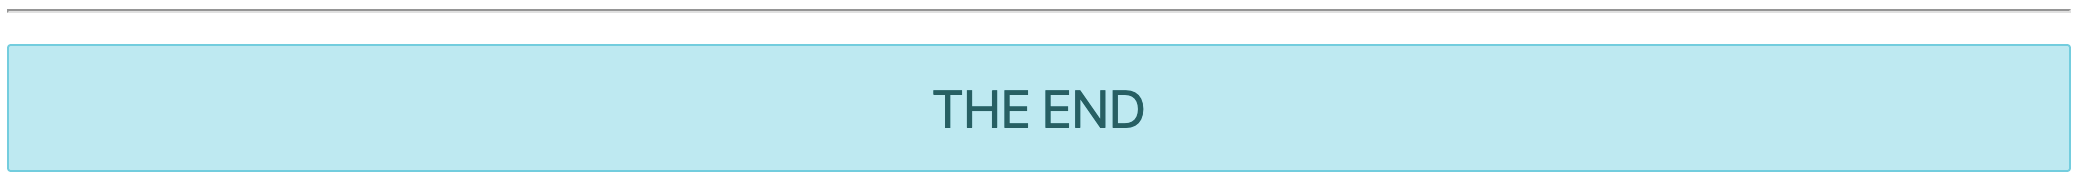